# Do the cleavage products behave as the literature says they do?

## Scope

`4_01` and `4_02` convert a cleavage event into a change in predicted activity.
Two separate things have to be right for that to mean anything.

1. The **fragment potency model**: given a product sequence, does the MIC
   predictor place it correctly relative to its parent?
2. The **mixture rule**: given the set of products, does the potency sum
   $\psi = \sum_i C_i / \mathrm{MIC}_i$ reproduce what the experiment observed
   about the digest as a whole?

The literature separates these for us. For LL-37 several proteases are known to
produce products whose activity was measured, and the outcomes disagree: some
cuts are **processing**, leaving active peptides behind, and others are
**inactivation**. A model that cannot tell those apart is not usable as a design
objective, whatever its internal statistics look like.

## The published outcomes

| Protease | Products | Published outcome | Source |
| --- | --- | --- | --- |
| V8 (`S01.269`) | LL-17-37 | retains anti-*S. aureus* activity | `10.1128/AAC.48.12.4673-4679.2004` |
| KLK5 / KLK7 | RK-31 (7-37), KS-30 (8-37), KR-20 (18-37) | all retain antimicrobial activity | `10.1096/fj.06-6075com` |
| aureolysin (`M04.009`) | 1-19, 20-23, 24-31, 32-37 | activity abolished immediately | `10.1128/AAC.48.12.4673-4679.2004` |

The V8 product and the three kallikrein products are the positives; the four
aureolysin products are the negatives. The complementary V8 product `1-16` is
**not** labelled, because the source states only that `17-37` retains activity
and says nothing about the other half; it is computed and reported apart from the
test rather than assigned a label it does not have.

## The confound, named in advance

The retained products are long (20 to 31 residues) and the abolished ones are
short (4 to 19). A MIC predictor that did nothing but read length would separate
them perfectly. Every comparison here is therefore run twice: once raw, and once
against every contiguous window of the parent of the same length, which holds
length fixed by construction and asks only whether *this* window is the good one.

## Inputs and outputs

Inputs: `configs/clasp-controls.tsv`, the APEX ensemble.

Outputs: `results/4_03_fragment_outcomes.csv`,
`results/4_03_length_control.csv`, `results/4_03_mixture_rule.csv`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

import _analysis_common as common
from pep_compass.optimization.components.oracles.strategies.apex.predictor import APEXPredictor

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
MIC_STRAIN = "A. baumannii ATCC 19606"
# The predictor returns the 34 APEX strains in the column order of the
# precomputed table, whose strain columns begin after the four metadata columns.
STRAIN_COLUMN = 0
MIN_WINDOW_LENGTH = 4

LL37 = "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES"
PRODUCTS = (
    ## Processing: the source measured activity in the product and found it retained
    ("LL-17-37", LL37[16:], "V8", "retains", "17-37"),
    ("RK-31", LL37[6:], "KLK5/KLK7", "retains", "7-37"),
    ("KS-30", LL37[7:], "KLK5/KLK7", "retains", "8-37"),
    ("KR-20", LL37[17:], "KLK5/KLK7", "retains", "18-37"),
    ## Inactivation: the source reports activity abolished by this digest
    ("aureolysin 1-19", LL37[:19], "aureolysin", "abolished", "1-19"),
    ("aureolysin 20-23", LL37[19:23], "aureolysin", "abolished", "20-23"),
    ("aureolysin 24-31", LL37[23:31], "aureolysin", "abolished", "24-31"),
    ("aureolysin 32-37", LL37[31:], "aureolysin", "abolished", "32-37"),
    ## Unlabelled: the complementary V8 product, whose activity the source does not state
    ("V8 1-16", LL37[:16], "V8", "not_stated", "1-16"),
)
## Length-matched engineered pairs, where the published outcome is a fold change in MIC
ENGINEERED = (
    ("EFK17", "EFKRIVQRIKDFLRNLV", "EFK17-W", "EWKRWVQRWKDWLRNLV", "4-8x improvement"),
    ("CAM", "KWKLFKKIEKVGQGIGAVLKVLTTGL", "CAM-W", "KWKLWKKIEKWGQGIGAVLKWLTTWL", "3-12x improvement"),
)

In [3]:
predictor = APEXPredictor(model="full", device="cpu")


def predict_mic(sequences: list[str]) -> np.ndarray:
    """Return the predicted MIC of each sequence on the reference strain.

    :param sequences: Peptide sequences.
    :return: Predicted MIC values ``(N,)`` in the units of the APEX ensemble.
    """

    return predictor.predict(sequences)[:, STRAIN_COLUMN]  # (N,)


print(f"parent LL-37, {len(LL37)} residues | products under test: {len(PRODUCTS)}")

parent LL-37, 37 residues | products under test: 9


## Predicted potency of the parent and of every published product

In [4]:
parent_mic = float(predict_mic([LL37])[0])
product_mic = predict_mic([sequence for _, sequence, _, _, _ in PRODUCTS])
fragments = pd.DataFrame(
    {
        "product": [name for name, _, _, _, _ in PRODUCTS],
        "span": [span for _, _, _, _, span in PRODUCTS],
        "protease": [protease for _, _, protease, _, _ in PRODUCTS],
        "outcome": [outcome for _, _, _, outcome, _ in PRODUCTS],
        "length": [len(sequence) for _, sequence, _, _, _ in PRODUCTS],
        "predicted_mic": product_mic,
    }
)
fragments["fold_change_vs_parent"] = fragments["predicted_mic"] / parent_mic
print(f"parent MIC {parent_mic:.1f}\n")
print(fragments.round(3).to_string(index=False))

labelled = fragments[fragments["outcome"] != "not_stated"]
abolished = labelled.loc[labelled["outcome"] == "abolished", "predicted_mic"].to_numpy()
retained = labelled.loc[labelled["outcome"] == "retains", "predicted_mic"].to_numpy()
statistic, raw_p = mannwhitneyu(abolished, retained, alternative="greater")
raw_auc = statistic / (len(abolished) * len(retained))
print(f"\nraw separation: AUC {raw_auc:.3f}, exact one-sided p {raw_p:.4f}")

parent MIC 82.3

         product  span   protease    outcome  length  predicted_mic  fold_change_vs_parent
        LL-17-37 17-37         V8    retains      21      82.988998                  1.008
           RK-31  7-37  KLK5/KLK7    retains      31      62.303001                  0.757
           KS-30  8-37  KLK5/KLK7    retains      30      72.795998                  0.884
           KR-20 18-37  KLK5/KLK7    retains      20      77.247002                  0.938
 aureolysin 1-19  1-19 aureolysin  abolished      19     107.521004                  1.306
aureolysin 20-23 20-23 aureolysin  abolished       4     136.645004                  1.660
aureolysin 24-31 24-31 aureolysin  abolished       8     131.412003                  1.596
aureolysin 32-37 32-37 aureolysin  abolished       6     136.703995                  1.661
         V8 1-16  1-16         V8 not_stated      16     133.024002                  1.616

raw separation: AUC 1.000, exact one-sided p 0.0143


## The length control

Every contiguous window of LL-37 down to four residues is scored. A product is
then placed among the windows of its own length: a percentile of $0$ means it is
the most potent window of that length, $1$ the least. This removes length from
the comparison entirely, so whatever separation survives is contributed by the
residues the protease happened to choose.

In [5]:
windows = [LL37[start : start + length] for length in range(MIN_WINDOW_LENGTH, len(LL37) + 1) for start in range(0, len(LL37) - length + 1)]
window_mic = predict_mic(windows)
window_frame = pd.DataFrame({"sequence": windows, "length": [len(w) for w in windows], "predicted_mic": window_mic})

percentiles = []
for row in fragments.itertuples():
    same_length = window_frame.loc[window_frame["length"] == row.length, "predicted_mic"].to_numpy()
    percentiles.append(
        {
            "product": row.product,
            "outcome": row.outcome,
            "length": row.length,
            "n_windows": len(same_length),
            "percentile": float(np.mean(same_length <= row.predicted_mic)),
        }
    )
length_control = pd.DataFrame(percentiles)
print(length_control.round(3).to_string(index=False))

controlled = length_control[length_control["outcome"] != "not_stated"]
statistic, controlled_p = mannwhitneyu(
    controlled.loc[controlled["outcome"] == "abolished", "percentile"].to_numpy(),
    controlled.loc[controlled["outcome"] == "retains", "percentile"].to_numpy(),
    alternative="greater",
)
controlled_auc = statistic / (len(abolished) * len(retained))
print(f"\nlength-controlled separation: AUC {controlled_auc:.3f}, exact one-sided p {controlled_p:.4f}")
print(f"best attainable p at four against four: {1 / 70:.4f}")

         product    outcome  length  n_windows  percentile
        LL-17-37    retains      21         17       0.647
           RK-31    retains      31          7       0.143
           KS-30    retains      30          8       0.625
           KR-20    retains      20         18       0.556
 aureolysin 1-19  abolished      19         19       0.947
aureolysin 20-23  abolished       4         34       0.912
aureolysin 24-31  abolished       8         30       0.333
aureolysin 32-37  abolished       6         32       0.750
         V8 1-16 not_stated      16         22       0.955

length-controlled separation: AUC 0.812, exact one-sided p 0.1000
best attainable p at four against four: 0.0143


### Reading the figure

The left panel is the raw predicted MIC against the parent's, products ordered by
length; the separation there is real but so is the length trend behind it. The
right panel is the same products after length is held fixed, so the vertical axis
is "how good is this window among all windows of its length". A separation that
survives the move from left to right is a specificity result; one that does not
is a length result.

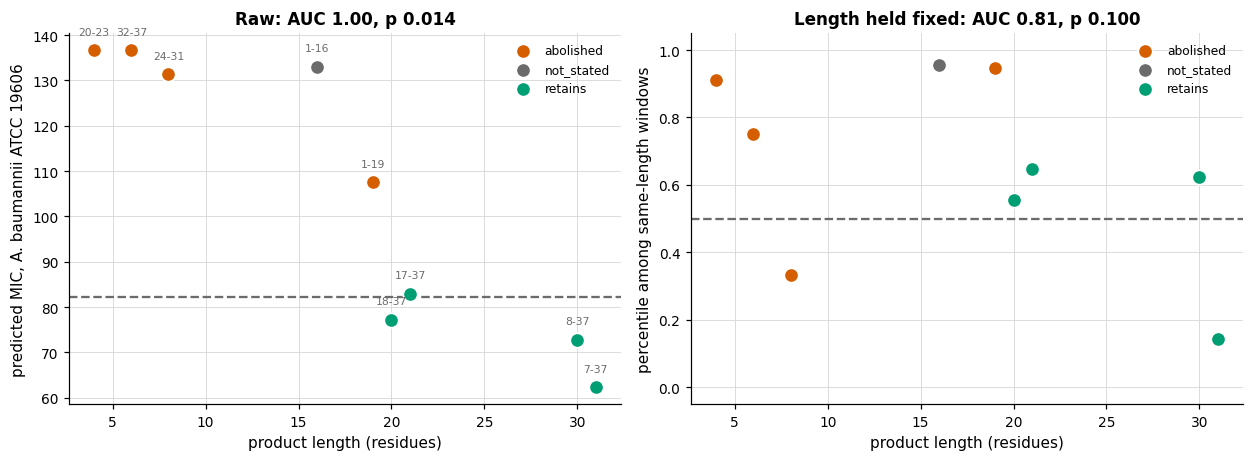

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
colour_of = {"retains": common.CATEGORICAL_COLORS[2], "abolished": common.CATEGORICAL_COLORS[1], "not_stated": common.NEUTRAL}

## Raw predicted MIC against length
ax = axes[0]
for outcome, group in fragments.groupby("outcome"):
    ax.scatter(group["length"], group["predicted_mic"], s=90, color=colour_of[outcome], edgecolor="white", linewidth=1.2, zorder=3, label=outcome)
ax.axhline(parent_mic, color=common.NEUTRAL, linestyle="--", linewidth=1.5)
ax.annotate("LL-37", (len(LL37), parent_mic), textcoords="offset points", xytext=(-6, 8), ha="right", fontsize=8, color=common.NEUTRAL)
for row in fragments.itertuples():
    ax.annotate(row.span, (row.length, row.predicted_mic), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=7, color=common.NEUTRAL)
ax.set_xlabel("product length (residues)")
ax.set_ylabel(f"predicted MIC, {MIC_STRAIN}")
ax.set_title(f"Raw: AUC {raw_auc:.2f}, p {raw_p:.3f}")
ax.legend(frameon=False, fontsize=8)

## Percentile among same-length windows of the parent
ax = axes[1]
for outcome, group in length_control.groupby("outcome"):
    ax.scatter(group["length"], group["percentile"], s=90, color=colour_of[outcome], edgecolor="white", linewidth=1.2, zorder=3, label=outcome)
ax.axhline(0.5, color=common.NEUTRAL, linestyle="--", linewidth=1.5)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("product length (residues)")
ax.set_ylabel("percentile among same-length windows")
ax.set_title(f"Length held fixed: AUC {controlled_auc:.2f}, p {controlled_p:.3f}")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## The mixture rule, tested against the same two digests

The products are now put back together the way `4_01` and `4_02` put them
together. Each fragment inherits the molar concentration of the parent, so the
potency sum of the digest relative to the intact peptide is

$$\frac{\psi_{\text{digest}}}{\psi_{\text{parent}}}
  = \mathrm{MIC}_{\text{parent}} \sum_{i} \frac{1}{\mathrm{MIC}_i},$$

a ratio below one meaning the digest is less potent. The published outcomes give
the expected sign directly: the aureolysin digest must fall well below one, and
the V8 digest must stay near one, since one of its two products is fully active.

The sum is then recomputed under a minimum-length guard: fragments shorter than
the guard are treated as inactive instead of receiving a prediction the MIC model
was never trained to make. Sweeping the guard shows which value, if any,
reproduces both published outcomes at once.

In [7]:
DIGESTS = {
    "aureolysin": (["1-19", "20-23", "24-31", "32-37"], "abolished"),
    "V8": (["1-16", "17-37"], "one product retains"),
}
mic_of_span = dict(zip(fragments["span"], fragments["predicted_mic"]))
length_of_span = dict(zip(fragments["span"], fragments["length"]))

sweep = []
for guard in range(0, 25):
    for digest, (spans, expectation) in DIGESTS.items():
        kept = [span for span in spans if length_of_span[span] >= guard]
        ratio = parent_mic * sum(1.0 / mic_of_span[span] for span in kept) if kept else 0.0
        sweep.append(
            {
                "minimum_length_guard": guard,
                "digest": digest,
                "published_expectation": expectation,
                "n_products_counted": len(kept),
                "potency_ratio": ratio,
                "log2_potency_change": float(np.log2(ratio)) if ratio > 0 else -np.inf,
            }
        )
mixture = pd.DataFrame(sweep)
print(mixture[mixture["minimum_length_guard"].isin([0, 4, 8, 16, 17, 20, 22])].round(3).to_string(index=False))

## A guard reproduces the literature when the aureolysin digest loses potency and
## the V8 digest does not
pivot = mixture.pivot_table(index="minimum_length_guard", columns="digest", values="potency_ratio")
consistent = pivot[(pivot["aureolysin"] < 1.0) & (pivot["V8"] >= 0.8)]
print("\nguards reproducing both published outcomes:", list(consistent.index))

 minimum_length_guard     digest published_expectation  n_products_counted  potency_ratio  log2_potency_change
                    0 aureolysin             abolished                   4          2.596                1.377
                    0         V8   one product retains                   2          1.611                0.688
                    4 aureolysin             abolished                   4          2.596                1.377
                    4         V8   one product retains                   2          1.611                0.688
                    8 aureolysin             abolished                   2          1.392                0.477
                    8         V8   one product retains                   2          1.611                0.688
                   16 aureolysin             abolished                   1          0.766               -0.385
                   16         V8   one product retains                   2          1.611                0.688
 

### Reading the figure

The potency ratio of each digest as the minimum-length guard rises. The shaded
band is where the model agrees with the literature on both digests at once: the
aureolysin curve must be below one and the V8 curve must not have collapsed. At
the guard of four residues used in `4_02` the aureolysin digest is predicted to be
more than twice as potent as the intact peptide, which is the opposite of the
published result.

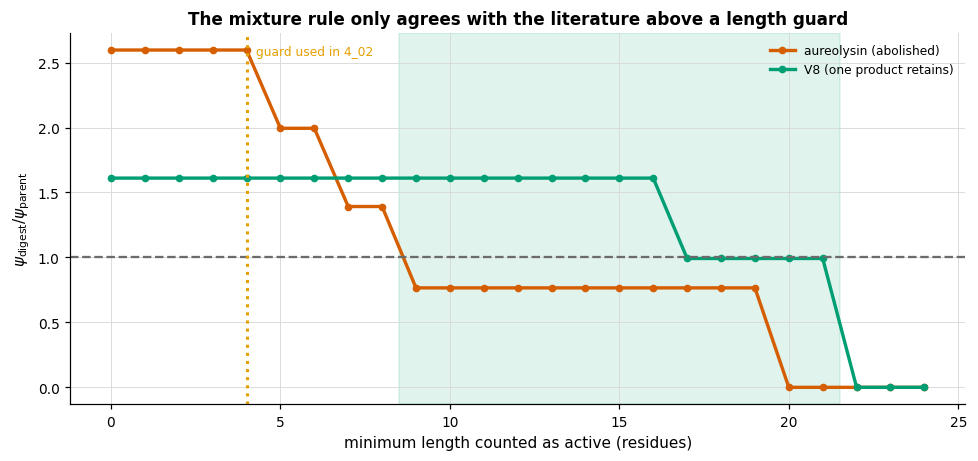

In [8]:
fig, ax = plt.subplots(figsize=(9.0, 4.3))
for position, (digest, colour) in enumerate(zip(DIGESTS, (common.CATEGORICAL_COLORS[1], common.CATEGORICAL_COLORS[2]))):
    subset = mixture[mixture["digest"] == digest]
    ax.plot(subset["minimum_length_guard"], subset["potency_ratio"], color=colour, linewidth=2.2, marker="o", markersize=4, label=f"{digest} ({DIGESTS[digest][1]})")
if len(consistent):
    ax.axvspan(consistent.index.min() - 0.5, consistent.index.max() + 0.5, color=common.CATEGORICAL_COLORS[2], alpha=0.12, zorder=0)
ax.axhline(1.0, color=common.NEUTRAL, linestyle="--", linewidth=1.5)
ax.axvline(4, color=common.CATEGORICAL_COLORS[3], linestyle=":", linewidth=2.0)
ax.annotate("guard used in 4_02", (4, ax.get_ylim()[1]), textcoords="offset points", xytext=(6, -14), fontsize=8, color=common.CATEGORICAL_COLORS[3])
ax.set_xlabel("minimum length counted as active (residues)")
ax.set_ylabel(r"$\psi_{\mathrm{digest}} / \psi_{\mathrm{parent}}$")
ax.set_title("The mixture rule only agrees with the literature above a length guard")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## The engineered pairs, on the activity side

`3_03` tested the Trp-substituted variants on the proteolysis side. The same two
pairs carry a published activity result, and it points the same way: the variants
are not only more stable but also more potent. This is a test of the MIC model
alone, on length-matched sequences, so length cannot contribute.

In [9]:
engineered_records = []
for parent_name, parent_sequence, variant_name, variant_sequence, published in ENGINEERED:
    values = predict_mic([parent_sequence, variant_sequence])
    engineered_records.append(
        {
            "pair": f"{parent_name} to {variant_name}",
            "length": len(parent_sequence),
            "parent_mic": float(values[0]),
            "variant_mic": float(values[1]),
            "predicted_fold_improvement": float(values[0] / values[1]),
            "published": published,
            "direction_correct": bool(values[1] < values[0]),
        }
    )
engineered = pd.DataFrame(engineered_records)
print(engineered.round(3).to_string(index=False))

            pair  length  parent_mic  variant_mic  predicted_fold_improvement         published  direction_correct
EFK17 to EFK17-W      17      38.255       46.931                       0.815  4-8x improvement              False
    CAM to CAM-W      26      27.185       36.285                       0.749 3-12x improvement              False


### Is the Trp failure specific to the reference strain?

The published fold changes were measured against *S. aureus* and *P. aeruginosa*
strains, while the comparison above is on the reference *A. baumannii* strain. If
the disagreement were a strain artefact it would disappear on the strains the
sources actually used. All thirty-four APEX strains are therefore scored, and the
strains named in the sources are marked.

In [10]:
strain_names = list(pd.read_csv(common.PEPTIDES_APEX_CSV, nrows=1).columns[4:])
PUBLISHED_STRAIN_TOKENS = ("aureus", "aeruginosa")
strain_records = []
for parent_name, parent_sequence, variant_name, variant_sequence, published in ENGINEERED:
    values = predictor.predict([parent_sequence, variant_sequence])  # (2, S)
    fold = values[0] / values[1]  # (S,)
    for position, strain in enumerate(strain_names):
        strain_records.append(
            {
                "pair": f"{parent_name} to {variant_name}",
                "strain": strain,
                "predicted_fold_improvement": float(fold[position]),
                "in_published_species": any(token in strain for token in PUBLISHED_STRAIN_TOKENS),
                "published": published,
            }
        )
strains = pd.DataFrame(strain_records)
summary = strains.groupby("pair")["predicted_fold_improvement"].agg(
    strains_improved=lambda values: int((values > 1).sum()),
    median="median",
    maximum="max",
)
summary["n_strains"] = len(strain_names)
print(summary.round(3).to_string())
print("\non the species the sources used:")
print(
    strains[strains["in_published_species"]]
    .pivot_table(index="strain", columns="pair", values="predicted_fold_improvement")
    .round(2)
    .to_string()
)

                  strains_improved  median  maximum  n_strains
pair                                                          
CAM to CAM-W                     3   0.681    1.220         34
EFK17 to EFK17-W                10   0.908    1.595         34

on the species the sources used:
pair                              CAM to CAM-W  EFK17 to EFK17-W
strain                                                          
P. aeruginosa PA01                        0.94              1.17
P. aeruginosa PA14                        0.73              0.81
S. aureus (ATCC BAA-1556) - MRSA          1.03              0.71
S. aureus ATCC 12600                      0.74              1.26


### Reading the figure

Each point is one strain. The dashed line at $1$ separates a variant predicted
more potent than its parent from one predicted less potent; the shaded band is
the fold range the sources report. Points from the species the sources used are
filled. A strain artefact would put the filled points inside the band.

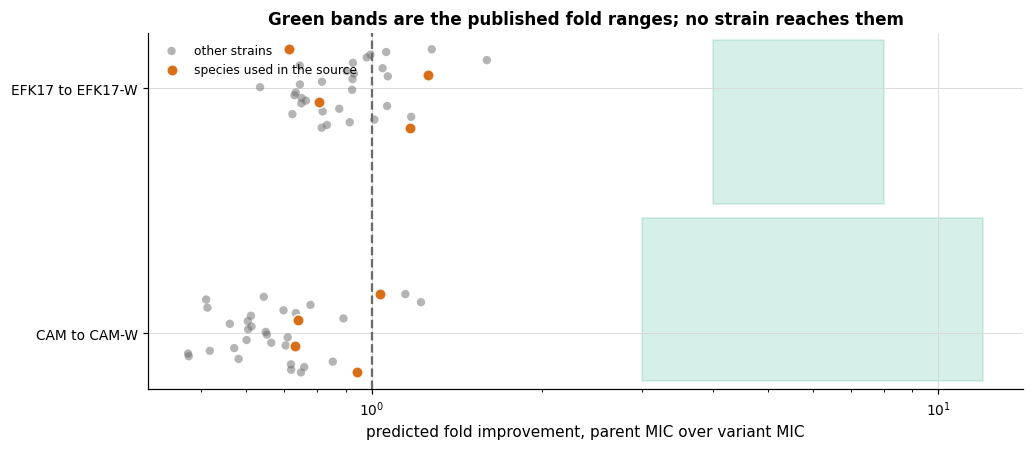

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for position, (pair, group) in enumerate(strains.groupby("pair")):
    for filled, subset in group.groupby("in_published_species"):
        ax.scatter(
            subset["predicted_fold_improvement"],
            np.full(len(subset), position) + np.linspace(-0.16, 0.16, len(subset)),
            s=55 if filled else 30,
            color=common.CATEGORICAL_COLORS[1] if filled else common.NEUTRAL,
            alpha=0.9 if filled else 0.5,
            edgecolor="white" if filled else "none",
            linewidth=1.0,
            zorder=3 if filled else 2,
            label=("species used in the source" if filled else "other strains") if position == 0 else None,
        )
## The reported ranges: 4-8x for EFK17-W, 3-12x for CAM-W
ax.axvspan(4, 8, ymin=0.52, ymax=0.98, color=common.CATEGORICAL_COLORS[2], alpha=0.16, zorder=0)
ax.axvspan(3, 12, ymin=0.02, ymax=0.48, color=common.CATEGORICAL_COLORS[2], alpha=0.16, zorder=0)
ax.axvline(1.0, color=common.NEUTRAL, linestyle="--", linewidth=1.5)
ax.set_xscale("log")
ax.set_yticks(range(len(summary)))
ax.set_yticklabels(summary.index)
ax.set_xlabel("predicted fold improvement, parent MIC over variant MIC")
ax.set_title("Green bands are the published fold ranges; no strain reaches them")
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

In [12]:
common.save_result(strains, "4_03_engineered_strain_sweep.csv")
common.save_result(fragments, "4_03_fragment_outcomes.csv")
common.save_result(length_control, "4_03_length_control.csv")
common.save_result(mixture, "4_03_mixture_rule.csv")
common.save_result(engineered, "4_03_engineered_pairs.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/4_03_engineered_pairs.csv')

## What this establishes

**The three components tested here do not stand or fall together.**

**The fragment potency model ranks the published products correctly.** Every
product the literature reports as retaining activity is predicted more potent
than every product of the digest that abolished it: raw AUC $1.00$, exact
one-sided $p = 0.014$, which is the best a four-against-four comparison can do.
Holding length fixed costs some of that but not most of it — AUC $0.81$,
$p = 0.10$ — so the ordering is not purely a length trend, though with eight
products the length-controlled test cannot reach significance and should be read
as consistent rather than as confirming. The ordering is also correct in detail:
`RK-31` and `KS-30`, which several sources report as **more** active than the
parent, are the two most potent products predicted.

**The mixture rule is wrong at the settings the earlier notebooks use.** With
every fragment counted, the aureolysin digest — the one the source describes as
abolishing activity immediately — is predicted to be $2.6\times$ *more* potent
than the intact peptide. The error is not in the additivity; it is that a
four-residue fragment lies outside the MIC model's domain and comes back with a
number only $1.7\times$ worse than the parent's, while four such fragments each
inherit the parent's molar concentration. A minimum-length guard between $9$ and
$21$ residues reproduces both published digests at once: the aureolysin digest
loses potency and the V8 digest, one of whose two products is fully active, does
not. The guard of four residues used in `4_02` sits well below that range.

**The MIC model fails on the Trp-substituted pairs.** The sources report EFK17-W
as $4$ to $8\times$ more potent than EFK17 and CAM-W as $3$ to $12\times$ more
potent than CAM. The predictor puts both variants *less* potent than their
parents, $0.82\times$ and $0.75\times$ on the reference strain. The strain sweep
rules out the obvious escape: across all thirty-four APEX strains EFK17-W is
predicted more potent on ten, median fold $0.91$, and CAM-W on three, median
$0.68$; on the species the sources actually used the folds run from $0.71$ to
$1.26$, against published ranges of $4$-$8\times$ and $3$-$12\times$. These are
length-matched pairs differing in four residues, so nothing else can be blamed. Trp substitution is exactly the
modification that `3_03` found the proteolysis side handles well, and it is the
modification the activity side gets backwards. Any design objective combining the
two will be pulled in opposite directions on precisely the class of variants the
literature says works.

**Consequences for the earlier notebooks.**

1. The negative median log2 potency loss reported in `4_01` — the finding that
   the first cut *raises* the potency sum on average — is an artefact of the
   unguarded mixture rule and must not be read biologically. `4_01` and `4_02`
   should be re-run with a guard inside the range found here.
2. The bond ranking those notebooks rest on is unaffected, since `3_02` validates
   it without reference to any MIC.
3. Conclusions about which *engineered variant* is better cannot be drawn from
   this MIC model until the Trp failure is understood.

**Limits.** One parent peptide, two digests, eight labelled products, and the
activity outcomes are qualitative statements from the sources rather than
measured MICs of the isolated fragments. The guard range is calibrated on those
two digests alone and is an order of magnitude, not a fitted parameter. The
engineered-pair result rests on two pairs, which is few, but the strain sweep
removes the one confound that could have explained it away, so within those two
pairs the disagreement is systematic rather than incidental.